# Axion PINN V5 — Physics-Informed Neural Network for Axion Cosmology

## Overview

This notebook implements a **Physics-Informed Neural Network (PINN)** in PyTorch to solve the
coupled ODE system governing axion dynamics in a flat FLRW universe.

| Component | Description |
|---|---|
| **Equations** | Friedmann (scale factor) + Klein-Gordon (axion field) |
| **Architecture** | Two sub-networks with hard initial conditions |
| **Precision** | `torch.float64` throughout |
| **Training** | Adam → L-BFGS two-phase strategy |
| **Reference** | High-accuracy `RK45` ODE solution for comparison |

---

## Equations of Motion

### Equation 1 — Friedmann (scale factor)
$$
\dot{a} = \frac{1}{\sqrt{3}}
\left(
  \frac{1}{2}\dot{\phi}^{2}
  + \frac{1}{2}m_a^2\phi^2
  + \frac{\rho_m}{a}
  + \frac{\rho_r}{a^2}
  + \rho_\Lambda a^2
\right)^{1/2}
$$

### Equation 2 — Klein-Gordon (axion field)
$$
\ddot{\phi}
+ \sqrt{3}
\left(
  \frac{1}{2}\dot{\phi}^{2}
  + \frac{1}{2}m_a^2 \phi^2
  + \frac{\rho_m}{a^3}
  + \frac{\rho_r}{a^4}
  + \rho_\Lambda
\right)^{1/2}
\dot{\phi}
+ m_a^2\,\phi = 0
$$

### Initial Conditions
$$
a(0) = 10^{-8}, \quad \phi(0) = 1, \quad \dot{\phi}(0) = 0
$$

### Parameters
- $m_a = 100$ (axion mass), with three background densities: $\rho_m$, $\rho_r$, $\rho_\Lambda$

---

## PINN Architecture Summary

```
AxionPINN
├── ScaleFactorNet  →  a(t) = a₀ · exp(clamp(Δt · g_net(t), max=40))
│       Hard IC: a(t₀) = a₀ (exact), always positive, overflow-safe
└── PhiNet          →  φ(t) = φ₀ + φ̇₀·Δt + Δt² · h_net(t)
        Hard IC: φ(t₀) = φ₀, φ̇(t₀) = φ̇₀ (exact)
```


In [1]:
"""
Imports and global configuration.
All computation uses torch.float64 for numerical accuracy.
"""

import os
import time
import warnings
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp

# ── Globals ───────────────────────────────────────────────────────────────────
DTYPE  = torch.float64                          # float64 for numerical precision
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30                                  # numerical safety floor

torch.set_default_dtype(DTYPE)                  # make float64 the default

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
print(f"Precision: {DTYPE}")


PyTorch  : 2.12.0+cpu
Device   : cpu
Precision: torch.float64


---
## Neural Network Architecture

### Design Philosophy

| Concern | Solution |
|---|---|
| $a(t)$ spans 8+ orders of magnitude | Log-space parameterization with clamped exponent |
| $\phi(t)$ oscillates rapidly for large $m_a$ | Sin activation captures oscillatory structure |
| IC enforcement | Hard ICs baked into network architecture (always exact) |
| Overflow at $a \to 0$ | Clamp $a_{\rm safe} = \max(a, \varepsilon)$ in density terms |

### Sub-network Summaries

**`ScaleFactorNet`**
$$
a(t) = a_0 \cdot \exp\!\bigl(\text{clamp}(\Delta t \cdot g_{\rm net}(t),\ \text{max}=40)\bigr)
$$
- $\Delta t = t - t_0$ ensures $a(t_0) = a_0$ exactly
- Exponential ensures $a > 0$ always
- Clamp to 40 prevents overflow ($e^{40} \approx 2.4\times10^{17}$)

**`PhiNet`**
$$
\phi(t) = \phi_0 + \dot{\phi}_0\,\Delta t + \Delta t^2 \cdot h_{\rm net}(t)
$$
- Taylor anchor enforces ICs exactly at $t_0$
- $\Delta t^2$ factor makes $\phi(t_0) = \phi_0$ and $\dot\phi(t_0) = \dot\phi_0$ exact
- Sin activation helps capture rapid oscillations ($m_a = 100$)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. SinActivation  ─  elementwise sin(x)
#    Captures oscillatory structure in phi(t) without extra engineering.
# ─────────────────────────────────────────────────────────────────────────────
class SinActivation(nn.Module):
    """Elementwise sine activation: sin(x).  Useful for oscillatory fields."""
    def forward(self, x):
        return torch.sin(x)


# ─────────────────────────────────────────────────────────────────────────────
# 2. FCNN  ─  Fully Connected Neural Network
#    Configurable depth, width, and activation (tanh | sin).
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    """
    Fully connected MLP.

    Args:
        in_dim     : input dimension (1 for scalar t)
        out_dim    : output dimension
        hidden     : neurons per hidden layer
        depth      : number of hidden layers
        activation : 'tanh' (smooth, bounded) or 'sin' (oscillatory)
    """
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4, activation='tanh'):
        super().__init__()

        # Create a FRESH activation instance per layer to avoid sharing the
        # same nn.Module object in nn.Sequential (would cause duplicate keys).
        def _act():
            return nn.Tanh() if activation == 'tanh' else SinActivation()

        layers = [nn.Linear(in_dim, hidden), _act()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), _act()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)

        # Xavier init for Tanh; Kaiming (linear) for Sin
        self._init_weights(activation)

    def _init_weights(self, activation):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                if activation == 'tanh':
                    nn.init.xavier_uniform_(m.weight)
                else:
                    nn.init.kaiming_uniform_(m.weight, nonlinearity='linear')
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


# ─────────────────────────────────────────────────────────────────────────────
# 3. ScaleFactorNet  ─  Hard IC for a(t)
#
#   Parameterisation (log-space):
#       a(t) = a₀ · exp( clamp( Δt · g_net(t), max=40 ) )
#       where Δt = t - t₀
#
#   Properties:
#       ✓  a(t₀) = a₀  — exact hard IC
#       ✓  a(t)  > 0   — always (exponential)
#       ✓  Overflow-safe: exp clamped at 40  (e⁴⁰ ≈ 2.4 × 10¹⁷)
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet(nn.Module):
    """Scale factor network with hard IC and log-space parameterisation."""

    def __init__(self, a0, t0, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('log_a0', torch.tensor(np.log(float(a0)), dtype=DTYPE))
        self.register_buffer('t0',     torch.tensor(float(t0),         dtype=DTYPE))
        # Tanh activation: smooth, bounded — good for slowly-varying envelope
        self.net = FCNN(in_dim=1, out_dim=1, hidden=hidden, depth=depth, activation='tanh')

    def forward(self, t):
        dt       = t - self.t0                           # (N, 1)
        g        = self.net(t)                           # learned growth rate
        exponent = torch.clamp(dt * g, max=40.0)         # overflow protection
        return torch.exp(self.log_a0 + exponent)         # a₀ · exp(·)


# ─────────────────────────────────────────────────────────────────────────────
# 4. PhiNet  ─  Hard IC for φ(t)
#
#   Parameterisation:
#       φ(t) = φ₀ + φ̇₀·Δt + Δt² · h_net(t)
#
#   Properties:
#       ✓  φ(t₀)  = φ₀    — exact (Δt=0 → correction vanishes)
#       ✓  φ̇(t₀) = φ̇₀   — exact (d/dt[Δt²·h]|_{Δt=0} = 0)
#       Sin activation encodes oscillatory behaviour for high-m regime.
# ─────────────────────────────────────────────────────────────────────────────
class PhiNet(nn.Module):
    """Axion field network with hard IC enforced via Taylor anchor."""

    def __init__(self, phi0, dphi0, t0, hidden=128, depth=5):
        super().__init__()
        self.register_buffer('phi0',  torch.tensor(float(phi0),  dtype=DTYPE))
        self.register_buffer('dphi0', torch.tensor(float(dphi0), dtype=DTYPE))
        self.register_buffer('t0',    torch.tensor(float(t0),    dtype=DTYPE))
        # Sin activation: naturally encodes oscillatory field φ(t) for mₐ=100
        self.net = FCNN(in_dim=1, out_dim=1, hidden=hidden, depth=depth, activation='sin')

    def forward(self, t):
        dt = t - self.t0               # (N, 1)
        h  = self.net(t)               # residual correction from the network
        return self.phi0 + self.dphi0 * dt + dt**2 * h


# ─────────────────────────────────────────────────────────────────────────────
# 5. AxionPINN  ─  Combined model: outputs a(t) and φ(t)
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN(nn.Module):
    """
    Combined Physics-Informed Neural Network for axion cosmology.

    Outputs:
        a(t)   — scale factor  (always positive, IC exact)
        phi(t) — axion field   (IC exact for both value and derivative)
    """
    def __init__(self, a0, phi0, dphi0, t0,
                 a_hidden=64,    a_depth=4,
                 phi_hidden=128, phi_depth=5):
        super().__init__()
        self.a_net   = ScaleFactorNet(a0,         t0, a_hidden,   a_depth)
        self.phi_net = PhiNet(phi0, dphi0,         t0, phi_hidden, phi_depth)

    def forward(self, t):
        """
        Args:
            t : (N, 1) float64 tensor, requires_grad=True for autograd

        Returns:
            a   : (N, 1) — scale factor
            phi : (N, 1) — axion field
        """
        return self.a_net(t), self.phi_net(t)


# ── Quick sanity check ────────────────────────────────────────────────────────
_test_t = torch.linspace(1e-10, 1.0, 5, dtype=DTYPE).reshape(-1, 1).to(device)
_test_m = AxionPINN(a0=1e-8, phi0=1.0, dphi0=0.0, t0=1e-10).to(device)
_a, _phi = _test_m(_test_t)
print("Architecture test passed:")
print(f"  a_net   output shape : {_a.shape}  | a(t₀) = {_a[0,0].item():.3e}  (expected ~1e-8)")
print(f"  phi_net output shape : {_phi.shape} | φ(t₀) = {_phi[0,0].item():.6f} (expected 1.0)")
del _test_t, _test_m, _a, _phi

print("\nClasses defined: SinActivation, FCNN, ScaleFactorNet, PhiNet, AxionPINN")


Architecture test passed:
  a_net   output shape : torch.Size([5, 1])  | a(t₀) = 1.000e-08  (expected ~1e-8)
  phi_net output shape : torch.Size([5, 1]) | φ(t₀) = 1.000000 (expected 1.0)

Classes defined: SinActivation, FCNN, ScaleFactorNet, PhiNet, AxionPINN


---
## Physical Parameters and ODE Reference

### Parameter Values

| Symbol | Value | Meaning |
|---|---|---|
| $m_a$ | 100 | Axion mass |
| $\rho_m$ | 0.81 | Matter density at $a=1$ |
| $\rho_r$ | $2.7138\times10^{-4}$ | Radiation density at $a=1$ |
| $\rho_\Lambda$ | 2.19 | Cosmological constant |
| $a_0$ | $10^{-8}$ | Initial scale factor |
| $\phi_0$ | 1.0 | Initial axion field value |
| $\dot\phi_0$ | 0.0 | Initial axion field velocity |

### ODE Reference Strategy

The same equations implemented as a NumPy/SciPy ODE are solved with `RK45` at
`rtol=1e-10`, `atol=1e-13` to obtain a high-accuracy reference for comparison.

> **Note on the two energy densities:**  
> Eq. 1 uses $(a^{-1},\,a^{-2},\,a^2)$ scaling for background densities,  
> while Eq. 2 uses the standard $(a^{-3},\,a^{-4},\,1)$ form.  
> Both are implemented faithfully as provided.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Physical parameters  (edit here to run different configurations)
# ─────────────────────────────────────────────────────────────────────────────
PARAMS = {
    'ma'      : 100.0,          # axion mass                       [mₐ]
    'rho_m0'  : 0.81,           # matter density at a=1            [ρ_m]
    'rho_r0'  : 2.7138e-4,      # radiation density at a=1         [ρ_r]
    'rho_L'   : 2.19,           # cosmological constant             [ρ_Λ]
    'a0'      : 1e-8,           # initial scale factor              [a₀]
    'phi0'    : 1.0,            # initial axion field               [φ₀]
    'dphi0'   : 0.0,            # initial axion field velocity      [φ̇₀]
    't_init'  : 1e-10,          # start time (avoids t=0 singularity)
    't_end'   : 1.0,            # end time
}

# ─────────────────────────────────────────────────────────────────────────────
# Physics residual utilities (PyTorch, used inside PINN loss)
# ─────────────────────────────────────────────────────────────────────────────

def _rho_bg_eq1(a, rho_m0, rho_r0, rho_L):
    """
    Background energy-density contribution in Friedmann Eq 1:
        ρ_m0 / a  +  ρ_r0 / a²  +  ρ_Λ · a²
    (uses a^{-1}, a^{-2}, a^2 scaling as given)
    """
    a_s = torch.clamp(a, min=EPS)          # guard against a→0
    return rho_m0 / a_s + rho_r0 / a_s**2 + rho_L * a**2


def _rho_bg_eq2(a, rho_m0, rho_r0, rho_L):
    """
    Background energy-density contribution in Klein-Gordon Eq 2:
        ρ_m0 / a³  +  ρ_r0 / a⁴  +  ρ_Λ
    (standard cosmological form)
    """
    a_s = torch.clamp(a, min=EPS)
    return rho_m0 / a_s**3 + rho_r0 / a_s**4 + rho_L


def compute_physics_residuals(a, phi, a_t, phi_t, phi_tt,
                               ma, rho_m0, rho_r0, rho_L, dev):
    """
    Compute physics residuals for both equations.

    Residual 1 (Friedmann):
        R_F  = ȧ − (1/√3)·√( ½φ̇² + ½m²φ² + ρ_m/a + ρ_r/a² + ρ_Λa² )

    Residual 2 (Klein-Gordon):
        R_KG = φ̈ + √3·√( ½φ̇² + ½m²φ² + ρ_m/a³ + ρ_r/a⁴ + ρ_Λ )·φ̇ + m²φ

    Args:
        a, phi           : network outputs  (N,1)
        a_t, phi_t       : first derivatives (N,1)
        phi_tt           : second derivative of phi (N,1)
        ma, rho_m0, ...  : scalar torch tensors or floats

    Returns:
        R_F, R_KG : residual tensors (N, 1)
    """
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=dev).sqrt()

    axion_rho = 0.5 * phi_t**2 + 0.5 * ma**2 * phi**2   # axion energy density (both eq.)

    # ── Friedmann (Eq 1) ─────────────────────────────────────────────────────
    E1       = axion_rho + _rho_bg_eq1(a, rho_m0, rho_r0, rho_L)
    H_eff1   = torch.sqrt(torch.clamp(E1 / 3.0, min=0.0) + EPS)
    R_F      = a_t - H_eff1                                # ȧ - (1/√3)√E1

    # ── Klein-Gordon (Eq 2) ───────────────────────────────────────────────────
    E2       = axion_rho + _rho_bg_eq2(a, rho_m0, rho_r0, rho_L)
    H_eff2   = torch.sqrt(torch.clamp(E2 / 3.0, min=0.0) + EPS)
    R_KG     = phi_tt + sqrt3 * H_eff2 * phi_t + ma**2 * phi

    return R_F, R_KG


# ─────────────────────────────────────────────────────────────────────────────
# ODE reference  (NumPy/SciPy, same equations for validation)
# ─────────────────────────────────────────────────────────────────────────────

def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    """
    Right-hand side of the ODE system:
        dy/dt = [da/dt, dphi/dt, dphi_dot/dt]
    Implements the user-specified equations exactly.
    """
    a, phi, phi_dot = y
    a_safe = max(a, 1e-30)

    axion_rho = 0.5 * phi_dot**2 + 0.5 * ma**2 * phi**2

    # Friedmann Eq 1: da/dt = (1/√3)·√(axion_rho + ρ_m/a + ρ_r/a² + ρ_Λa²)
    E1    = axion_rho + rho_m0/a_safe + rho_r0/a_safe**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0) / 3.0)

    # Klein-Gordon Eq 2: φ̈ = -√3·H₂·φ̇ - m²φ
    E2           = axion_rho + rho_m0/a_safe**3 + rho_r0/a_safe**4 + rho_L
    H2           = np.sqrt(max(E2, 0.0) / 3.0)
    dphi_dot_dt  = -np.sqrt(3.0) * H2 * phi_dot - ma**2 * phi

    return [da_dt, phi_dot, dphi_dot_dt]


def solve_reference_ode(params, n_eval=5000):
    """
    Solve the ODE system with high-accuracy RK45 for reference comparison.

    Returns:
        sol — scipy OdeSolution with sol.t (times) and sol.y (states)
    """
    t_span = (params['t_init'], params['t_end'])
    y0     = [params['a0'], params['phi0'], params['dphi0']]
    args   = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])

    # Log-spaced evaluation grid: resolves early-time dynamics well
    t_eval = np.logspace(np.log10(t_span[0]), np.log10(t_span[1]), n_eval)

    print("Solving ODE reference (RK45, rtol=1e-10)...")
    t0  = time.time()
    sol = solve_ivp(_ode_rhs, t_span, y0,
                    t_eval=t_eval, method='RK45',
                    rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done in {time.time()-t0:.2f}s | success={sol.success} | "
          f"nfev={sol.nfev}")
    if not sol.success:
        warnings.warn(f"ODE solver: {sol.message}")
    return sol


print("Functions defined: _rho_bg_eq1, _rho_bg_eq2, compute_physics_residuals, "
      "_ode_rhs, solve_reference_ode")


Functions defined: _rho_bg_eq1, _rho_bg_eq2, compute_physics_residuals, _ode_rhs, solve_reference_ode


---
## PINN Solver

### Loss Function

$$
\mathcal{L}_{\rm total}
= \underbrace{\mathcal{L}_F + w_{\rm KG}\,\mathcal{L}_{\rm KG}}_{\mathcal{L}_{\rm physics}}
+ \lambda_{\rm IC}\,\mathcal{L}_{\rm IC}
$$

where each term is:

$$
\mathcal{L}_F   = \frac{1}{N}\sum_i \left(\frac{R_F^{(i)}}{\sigma_F}\right)^2, \quad
\mathcal{L}_{\rm KG} = \frac{1}{N}\sum_i \left(\frac{R_{\rm KG}^{(i)}}{\sigma_{\rm KG}}\right)^2
$$

Residuals are normalised by their batch-mean absolute values
($\sigma_F$, $\sigma_{\rm KG}$) to balance the two equations automatically.

$$
\mathcal{L}_{\rm IC}
= \left(\ln\frac{a(t_0)}{a_0}\right)^2
+ \bigl(\phi(t_0)-\phi_0\bigr)^2
+ \bigl(\dot\phi(t_0)-\dot\phi_0\bigr)^2
$$

> With hard ICs embedded in the architecture all three IC terms are identically zero —
> $\mathcal{L}_{\rm IC}$ serves only as a safety monitor.

### Training Strategy

| Phase | Method | Purpose |
|---|---|---|
| 1 | **Adam** + CosineAnnealingLR | Global landscape exploration, escape local minima |
| 2 | **L-BFGS** (strong Wolfe) | High-accuracy fine-tuning near the solution |

- Collocation resampled every `resample_every` epochs to avoid over-fitting fixed points.
- Gradient clipping (norm ≤ 1.0) prevents explosion for large $m_a$.
- Best checkpoint saved throughout; restored on NaN detection.


In [4]:
class AxionPINNSolver:
    """
    Physics-Informed Neural Network solver for the coupled axion cosmology system.

    Equations:
        Eq 1 (Friedmann): ȧ = (1/√3)·√(½φ̇² + ½m²φ² + ρ_m/a + ρ_r/a² + ρ_Λa²)
        Eq 2 (KG)       : φ̈ + √3·√(½φ̇² + ½m²φ² + ρ_m/a³ + ρ_r/a⁴ + ρ_Λ)·φ̇ + m²φ = 0

    Training:
        Phase 1 — Adam with CosineAnnealingLR + gradient clipping
        Phase 2 — L-BFGS fine-tuning (strong Wolfe line search)
    """

    def __init__(self, params, model,
                 lambda_ic=10.0, w_F=1.0, w_KG=1.0,
                 n_colloc=3000):
        """
        Args:
            params     : dict with all physical and IC parameters
            model      : AxionPINN instance (already sent to device)
            lambda_ic  : weight for IC loss (should be ~0 with hard ICs)
            w_F, w_KG  : relative weights of Friedmann vs KG loss
            n_colloc   : number of collocation points per batch
        """
        self.p         = params
        self.model     = model.to(device)
        self.lambda_ic = float(lambda_ic)
        self.w_F       = float(w_F)
        self.w_KG      = float(w_KG)
        self.n_colloc  = int(n_colloc)

        # Training loss history
        self.history = {'total': [], 'F': [], 'KG': [], 'IC': []}

        # Best-checkpoint state
        self._best_loss  = float('inf')
        self._best_state = None

        # Precompute torch scalar constants
        def _ts(val):
            return torch.tensor(float(val), dtype=DTYPE, device=device)

        self.ma      = _ts(params['ma'])
        self.rho_m   = _ts(params['rho_m0'])
        self.rho_r   = _ts(params['rho_r0'])
        self.rho_L   = _ts(params['rho_L'])
        self.a0_ref  = _ts(params['a0'])
        self.phi0_r  = _ts(params['phi0'])
        self.dphi0_r = _ts(params['dphi0'])

        # IC time as a plain float for creating fresh tensors each call
        self._t0_val = float(params['t_init'])

    # ── Collocation sampling (uniform in linear t) ────────────────────────────
    def _sample_collocation(self):
        """
        Draw `n_colloc` points uniformly in [t_init, t_end].
        Returns (N, 1) tensor with requires_grad=True for autograd.
        """
        t_lo = float(self.p['t_init'])
        t_hi = float(self.p['t_end'])
        t    = (torch.rand(self.n_colloc, 1, dtype=DTYPE, device=device)
                * (t_hi - t_lo) + t_lo)
        return t.requires_grad_(True)

    # ── Forward + autograd derivatives ────────────────────────────────────────
    def _compute_derivatives(self, t):
        """
        Run the model and compute time-derivatives via automatic differentiation.

        Returns:
            a, phi           — model outputs (N,1)
            a_t              — da/dt
            phi_t            — dφ/dt
            phi_tt           — d²φ/dt²
        """
        a, phi = self.model(t)

        # torch.autograd.grad with create_graph=True keeps the computation
        # graph alive so that higher-order derivatives can be taken.
        # retain_graph=True on the first two calls is required because a and
        # phi share the same graph; the first grad call would free it otherwise.
        a_t = torch.autograd.grad(
            a,   t, grad_outputs=torch.ones_like(a),
            create_graph=True, retain_graph=True
        )[0]

        phi_t = torch.autograd.grad(
            phi, t, grad_outputs=torch.ones_like(phi),
            create_graph=True, retain_graph=True
        )[0]

        phi_tt = torch.autograd.grad(
            phi_t, t, grad_outputs=torch.ones_like(phi_t),
            create_graph=True
        )[0]

        return a, phi, a_t, phi_t, phi_tt

    # ── Total loss ─────────────────────────────────────────────────────────────
    def _compute_loss(self, t):
        """
        Compute:
            L_total = w_F*L_F + w_KG*L_KG + lambda_ic*L_IC

        Returns:
            L_total  : scalar tensor (differentiable)
            Lf, Lkg, Lic : float scalars for logging
        """
        a, phi, a_t, phi_t, phi_tt = self._compute_derivatives(t)

        R_F, R_KG = compute_physics_residuals(
            a, phi, a_t, phi_t, phi_tt,
            self.ma, self.rho_m, self.rho_r, self.rho_L, device
        )

        # ── Normalise residuals by batch-mean scale ───────────────────────────
        # This balances Friedmann and KG losses automatically, even when
        # their characteristic magnitudes differ by orders of magnitude.
        scale_F  = torch.clamp(a_t.detach().abs().mean(),    min=1e-8)
        scale_KG = torch.clamp(phi_tt.detach().abs().mean(), min=1e-8)

        L_F  = torch.mean((R_F  / scale_F) **2)
        L_KG = torch.mean((R_KG / scale_KG)**2)

        # ── IC loss (zero with hard ICs; monitors any residual drift) ─────────
        # Create a FRESH tensor each call (avoid in-place grad modification).
        t0    = torch.tensor([[self._t0_val]], dtype=DTYPE, device=device,
                              requires_grad=True)
        a0_p, phi0_p = self.model(t0)
        phi0_t = torch.autograd.grad(
            phi0_p, t0, grad_outputs=torch.ones_like(phi0_p),
            create_graph=True
        )[0]

        L_IC = (
            (torch.log(a0_p   + EPS) - torch.log(self.a0_ref  + EPS))**2
          + (phi0_p                   - self.phi0_r                   )**2
          + (phi0_t                   - self.dphi0_r                  )**2
        ).squeeze()   # → scalar

        L_total = self.w_F * L_F + self.w_KG * L_KG + self.lambda_ic * L_IC

        return L_total, L_F.item(), L_KG.item(), L_IC.item()

    # ── Phase 1: Adam ──────────────────────────────────────────────────────────
    def train_adam(self, n_epochs=15000, lr=1e-3, grad_clip=1.0,
                   print_every=2000, resample_every=200):
        """
        Train with the Adam optimiser.

        Args:
            n_epochs      : training epochs
            lr            : initial learning rate
            grad_clip     : gradient clipping norm (prevents explosion for m=100)
            print_every   : logging frequency
            resample_every: redraw collocation points every N steps
        """
        opt = optim.Adam(self.model.parameters(), lr=lr)
        # CosineAnnealing: smooth LR decay from lr → lr×0.01
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr * 0.01)

        print(f"\n{'='*65}")
        print(f"  Adam training  |  epochs={n_epochs}  lr={lr}  clip={grad_clip}")
        print(f"  n_colloc={self.n_colloc}  resample_every={resample_every}")
        print(f"{'='*65}")

        t_start = time.time()
        nan_streak = 0
        t_b = self._sample_collocation()   # initial collocation batch

        for ep in range(n_epochs):
            # Periodically resample to avoid over-fitting fixed quadrature points
            if ep % resample_every == 0:
                t_b = self._sample_collocation()

            opt.zero_grad()
            L, Lf, Lkg, Lic = self._compute_loss(t_b)
            L.backward()

            # Gradient clipping: critical for oscillatory fields with large m
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), grad_clip)
            opt.step()
            sch.step()

            lv = L.item()

            # ── NaN guard: restore best checkpoint and halve LR ───────────────
            if np.isnan(lv) or np.isinf(lv):
                nan_streak += 1
                if nan_streak >= 5 and self._best_state is not None:
                    print(f"  ⚠  NaN streak at ep {ep}: restoring checkpoint + halving LR")
                    self.model.load_state_dict(self._best_state)
                    for pg in opt.param_groups:
                        pg['lr'] *= 0.5
                    nan_streak = 0
                continue

            nan_streak = 0

            # Save best checkpoint
            if lv < self._best_loss:
                self._best_loss  = lv
                self._best_state = deepcopy(self.model.state_dict())

            self.history['total'].append(lv)
            self.history['F'].append(Lf)
            self.history['KG'].append(Lkg)
            self.history['IC'].append(Lic)

            if ep % print_every == 0 or ep == n_epochs - 1:
                lr_now = sch.get_last_lr()[0]
                print(f"  ep {ep:6d}/{n_epochs} | "
                      f"L={lv:.3e}  F={Lf:.3e}  KG={Lkg:.3e}  IC={Lic:.3e}  "
                      f"lr={lr_now:.2e}")

        elapsed = time.time() - t_start
        print(f"\n  Adam done in {elapsed:.1f}s | best_loss={self._best_loss:.3e}")

        # Restore best state found during training
        if self._best_state is not None:
            self.model.load_state_dict(self._best_state)
            print("  Restored best checkpoint.")

    # ── Phase 2: L-BFGS ───────────────────────────────────────────────────────
    def train_lbfgs(self, max_iter=1500, n_colloc=None):
        """
        Fine-tune with L-BFGS (quasi-Newton, strong Wolfe line search).
        Fixed collocation points are used throughout for a consistent objective.

        Args:
            max_iter : maximum L-BFGS iterations
            n_colloc : override collocation count (defaults to self.n_colloc)
        """
        old_nc = self.n_colloc
        if n_colloc is not None:
            self.n_colloc = int(n_colloc)

        print(f"\n{'='*65}")
        print(f"  L-BFGS refinement  |  max_iter={max_iter}  "
              f"n_colloc={self.n_colloc}")
        print(f"{'='*65}")

        # Fix the collocation set for the entire L-BFGS run
        t_f = self._sample_collocation()

        opt = optim.LBFGS(
            self.model.parameters(),
            lr=1.0, max_iter=max_iter,
            tolerance_grad=1e-11, tolerance_change=1e-13,
            history_size=100, line_search_fn='strong_wolfe'
        )

        it_count = [0]
        t0_wall  = time.time()

        def closure():
            opt.zero_grad()
            L, Lf, Lkg, Lic = self._compute_loss(t_f)
            L.backward()
            it_count[0] += 1
            if it_count[0] % 300 == 0:
                print(f"    iter {it_count[0]:4d} | "
                      f"L={L.item():.3e}  F={Lf:.3e}  KG={Lkg:.3e}")
            return L

        opt.step(closure)
        elapsed = time.time() - t0_wall
        print(f"\n  L-BFGS done in {elapsed:.1f}s | total_iters={it_count[0]}")

        self.n_colloc = old_nc  # restore


print("AxionPINNSolver defined with methods: train_adam(), train_lbfgs()")


AxionPINNSolver defined with methods: train_adam(), train_lbfgs()


---
## Evaluation and Visualisation

Plots produced:
1. **Solution comparison** — $a(t)$ and $\phi(t)$ against ODE reference (log-scale axes)
2. **Relative errors** — $|{\rm PINN} - {\rm ODE}|/|{\rm ODE}|$ over the full time domain
3. **Loss history** — Total, Friedmann, Klein-Gordon, and IC components vs. epoch


In [5]:
def evaluate_and_plot(solver, sol_ref, params, save_dir='results_v5', tag=''):
    """
    Evaluate the trained PINN and compare with ODE reference.

    Args:
        solver   : trained AxionPINNSolver
        sol_ref  : scipy OdeSolution from solve_reference_ode()
        params   : parameter dict
        save_dir : directory to save figures
        tag      : optional string appended to plot titles (e.g. 'm=100')

    Returns:
        a_pred, phi_pred : numpy arrays of PINN predictions
    """
    os.makedirs(save_dir, exist_ok=True)

    # ── PINN prediction on the ODE time grid ──────────────────────────────────
    t_np    = sol_ref.t.astype(np.float64)
    a_ref   = sol_ref.y[0]       # ODE a(t)
    phi_ref = sol_ref.y[1]       # ODE φ(t)

    solver.model.eval()
    with torch.no_grad():
        t_tensor = torch.tensor(t_np, dtype=DTYPE, device=device).reshape(-1, 1)
        a_t, phi_t = solver.model(t_tensor)

    a_pred   = a_t.cpu().numpy().flatten()
    phi_pred = phi_t.cpu().numpy().flatten()

    # NaN guard
    for name, arr in [('a_pred', a_pred), ('phi_pred', phi_pred)]:
        if np.isnan(arr).any():
            n = int(np.isnan(arr).sum())
            warnings.warn(f"⚠  {n} NaN values in {name} — possible overflow")

    _eps = 1e-30
    title_tag = f' ({tag})' if tag else ''
    ma_str    = f'$m_a = {params["ma"]:.0f}$'

    # ── Figure 1: Solution comparison ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    ax = axes[0]
    ax.loglog(t_np, a_ref,   'k--', lw=2,   label='ODE (RK45 reference)')
    ax.loglog(t_np, a_pred,  'r-',  lw=1.5, label='PINN V5')
    ax.set(xlabel='$t$', ylabel='$a(t)$',
           title=f'Scale Factor{title_tag}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogx(t_np, phi_ref,  'k--', lw=2,   label='ODE (RK45 reference)')
    ax.semilogx(t_np, phi_pred, 'b-',  lw=1.5, label='PINN V5')
    ax.set(xlabel='$t$', ylabel=r'$\phi(t)$',
           title=f'Axion Field{title_tag}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Axion PINN V5 — Solution Comparison  {ma_str}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'solution_v5.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Figure 2: Relative errors ──────────────────────────────────────────────
    rel_a   = np.abs(a_pred   - a_ref  ) / (np.abs(a_ref  ) + _eps)
    rel_phi = np.abs(phi_pred - phi_ref) / (np.abs(phi_ref).max() + _eps)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)

    ax = axes[0]
    ax.loglog(t_np, rel_a, 'r-', lw=1.2)
    ax.set(xlabel='$t$', ylabel='Relative error',
           title=r'$|a_{\rm PINN} - a_{\rm ODE}|\,/\,|a_{\rm ODE}|$')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.loglog(t_np, rel_phi, 'b-', lw=1.2)
    ax.set(xlabel='$t$', ylabel='Relative error',
           title=r'$|\phi_{\rm PINN} - \phi_{\rm ODE}|\,/\,\max|\phi_{\rm ODE}|$')
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Axion PINN V5 — Relative Errors  {ma_str}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'errors_v5.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Figure 3: Training loss history ───────────────────────────────────────
    if solver.history['total']:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)

        epochs = np.arange(len(solver.history['total']))

        ax = axes[0]
        ax.semilogy(epochs, solver.history['total'], 'b-',  lw=1.5, alpha=0.9, label='Total')
        ax.semilogy(epochs, solver.history['F'],     'g--', lw=1.0, alpha=0.8, label='Friedmann')
        ax.semilogy(epochs, solver.history['KG'],    'r--', lw=1.0, alpha=0.8, label='Klein-Gordon')
        ax.semilogy(epochs, solver.history['IC'],    'm:',  lw=1.0, alpha=0.7, label='IC')
        ax.set(xlabel='Epoch', ylabel='Loss', title='Training Loss — All Components')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        # Smoothed total loss (moving average)
        window = max(len(solver.history['total']) // 40, 1)
        total_arr    = np.array(solver.history['total'])
        total_smooth = np.convolve(total_arr, np.ones(window) / window, mode='valid')
        ax = axes[1]
        ax.semilogy(total_smooth, 'b-', lw=1.5,
                    label=f'Total loss (MA window={window})')
        ax.set(xlabel='Epoch', ylabel='Loss',
               title='Smoothed Total Loss (Adam)')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        plt.suptitle('Axion PINN V5 — Training Loss History',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        save_path = os.path.join(save_dir, 'loss_v5.png')
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"Saved: {save_path}")

    # ── IC verification and error summary ─────────────────────────────────────
    print('\n' + '='*65)
    print('  PINN V5 — IC Verification')
    print('='*65)
    print(f"  a(t_init)  : PINN={a_pred[0]:.6e}  |  ODE={a_ref[0]:.6e}"
          f"  |  true={params['a0']:.6e}")
    print(f"  φ(t_init)  : PINN={phi_pred[0]:.6f}  |  ODE={phi_ref[0]:.6f}"
          f"  |  true={params['phi0']:.6f}")

    print('\n' + '='*65)
    print('  PINN V5 — Global Error Metrics')
    print('='*65)
    print(f"  a(t)  : max_rel={rel_a.max():.3e}   mean_rel={rel_a.mean():.3e}")
    print(f"  φ(t)  : max_rel={rel_phi.max():.3e}  mean_rel={rel_phi.mean():.3e}")
    print('='*65)

    return a_pred, phi_pred


print("evaluate_and_plot() defined.")


evaluate_and_plot() defined.


---
## Full Training Pipeline

Steps:
1. **ODE reference** — high-accuracy `RK45` baseline
2. **Build model** — `AxionPINN` with `ScaleFactorNet` + `PhiNet`
3. **Adam** — 15 000 epochs, CosineAnnealing LR, gradient clipping
4. **L-BFGS** — 1 500 iterations, strong-Wolfe line search
5. **Evaluate** — compare PINN against ODE on 5 000-point log-spaced grid


In [6]:
# ── Smoke test: ODE reference + 200-epoch Adam to verify the full pipeline ────
# (Remove or skip this cell before the production run)

_sol_test = solve_reference_ode(PARAMS, n_eval=200)

_model_test = AxionPINN(
    a0=PARAMS['a0'], phi0=PARAMS['phi0'], dphi0=PARAMS['dphi0'],
    t0=PARAMS['t_init'], a_hidden=32, a_depth=3, phi_hidden=64, phi_depth=3,
).to(device)

_solver_test = AxionPINNSolver(
    params=PARAMS, model=_model_test,
    lambda_ic=10.0, w_F=1.0, w_KG=1.0, n_colloc=500,
)
_solver_test.train_adam(n_epochs=200, lr=1e-3, grad_clip=1.0,
                         print_every=100, resample_every=50)

# Check IC values at t_init
import torch
with torch.no_grad():
    _t0 = torch.tensor([[PARAMS['t_init']]], dtype=DTYPE, device=device)
    _at0, _pt0 = _model_test(_t0)
print(f"\nSmoke-test IC check:")
print(f"  a(t_init)  = {_at0.item():.4e}  (expected {PARAMS['a0']:.4e})")
print(f"  phi(t_init)= {_pt0.item():.6f}  (expected {PARAMS['phi0']:.6f})")
print("Smoke test PASSED — pipeline is connected end-to-end.")
del _sol_test, _model_test, _solver_test, _at0, _pt0, _t0


Solving ODE reference (RK45, rtol=1e-10)...


  Done in 0.31s | success=True | nfev=19748

  Adam training  |  epochs=200  lr=0.001  clip=1.0
  n_colloc=500  resample_every=50
  ep      0/200 | L=4.279e+28  F=1.333e+28  KG=2.946e+28  IC=0.000e+00  lr=1.00e-03
  ep    100/200 | L=1.354e+25  F=4.424e+23  KG=1.310e+25  IC=0.000e+00  lr=4.97e-04
  ep    199/200 | L=1.943e+23  F=1.474e+23  KG=4.690e+22  IC=0.000e+00  lr=1.00e-05

  Adam done in 3.4s | best_loss=1.623e+23
  Restored best checkpoint.

Smoke-test IC check:
  a(t_init)  = 1.0000e-08  (expected 1.0000e-08)
  phi(t_init)= 1.000000  (expected 1.000000)
Smoke test PASSED — pipeline is connected end-to-end.


In [7]:
t_pipeline = time.time()

# ─── Step 1: ODE reference solution ──────────────────────────────────────────
sol_ref = solve_reference_ode(PARAMS, n_eval=5000)

# ─── Step 2: Build AxionPINN model ────────────────────────────────────────────
model = AxionPINN(
    a0          = PARAMS['a0'],
    phi0        = PARAMS['phi0'],
    dphi0       = PARAMS['dphi0'],
    t0          = PARAMS['t_init'],
    # ScaleFactorNet: tanh, moderate depth
    a_hidden    = 64,
    a_depth     = 5,
    # PhiNet: sin activation, deeper for rapid oscillations (mₐ=100)
    phi_hidden  = 128,
    phi_depth   = 6,
).to(device, DTYPE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")
print(f"  ScaleFactorNet : {sum(p.numel() for p in model.a_net.parameters()):,}")
print(f"  PhiNet         : {sum(p.numel() for p in model.phi_net.parameters()):,}")

# ─── Step 3: Instantiate solver ───────────────────────────────────────────────
solver = AxionPINNSolver(
    params     = PARAMS,
    model      = model,
    lambda_ic  = 10.0,   # IC penalty weight (zero with hard ICs, for safety)
    w_F        = 1.0,    # Friedmann loss weight
    w_KG       = 1.0,    # Klein-Gordon loss weight
    n_colloc   = 3000,   # collocation points per step
)

# ─── Step 4: Phase 1 — Adam training ─────────────────────────────────────────
solver.train_adam(
    n_epochs       = 15000,
    lr             = 1e-4,
    grad_clip      = 1.0,     # clip gradient norms (important for mₐ=100)
    print_every    = 2000,
    resample_every = 200,     # resample collocation points periodically
)

# ─── Step 5: Phase 2 — L-BFGS fine-tuning ────────────────────────────────────
solver.train_lbfgs(
    max_iter = 1500,
    n_colloc = 4000,    # use more points for the final refinement step
)

print(f"\nTotal pipeline time: {time.time() - t_pipeline:.1f}s")


Solving ODE reference (RK45, rtol=1e-10)...
  Done in 0.34s | success=True | nfev=19748
Model parameters : 99,778
  ScaleFactorNet : 16,833
  PhiNet         : 82,945

  Adam training  |  epochs=15000  lr=0.0001  clip=1.0
  n_colloc=3000  resample_every=200
  ep      0/15000 | L=1.945e+28  F=9.361e+27  KG=1.009e+28  IC=0.000e+00  lr=1.00e-04
  ep   2000/15000 | L=6.689e+19  F=3.490e+13  KG=6.689e+19  IC=0.000e+00  lr=9.57e-05
  ep   4000/15000 | L=9.350e+19  F=5.679e+09  KG=9.350e+19  IC=0.000e+00  lr=8.36e-05
  ep   6000/15000 | L=9.909e+19  F=8.006e+06  KG=9.909e+19  IC=0.000e+00  lr=6.58e-05
  ep   8000/15000 | L=9.811e+19  F=2.358e+05  KG=9.811e+19  IC=0.000e+00  lr=4.53e-05
  ep  10000/15000 | L=9.764e+18  F=7.640e+03  KG=9.764e+18  IC=0.000e+00  lr=2.57e-05
  ep  12000/15000 | L=6.936e+19  F=4.876e+03  KG=6.936e+19  IC=0.000e+00  lr=1.04e-05
  ep  14000/15000 | L=1.266e+18  F=3.837e+03  KG=1.266e+18  IC=0.000e+00  lr=2.08e-06
  ep  14999/15000 | L=5.204e+16  F=4.721e+03  KG=5.204e

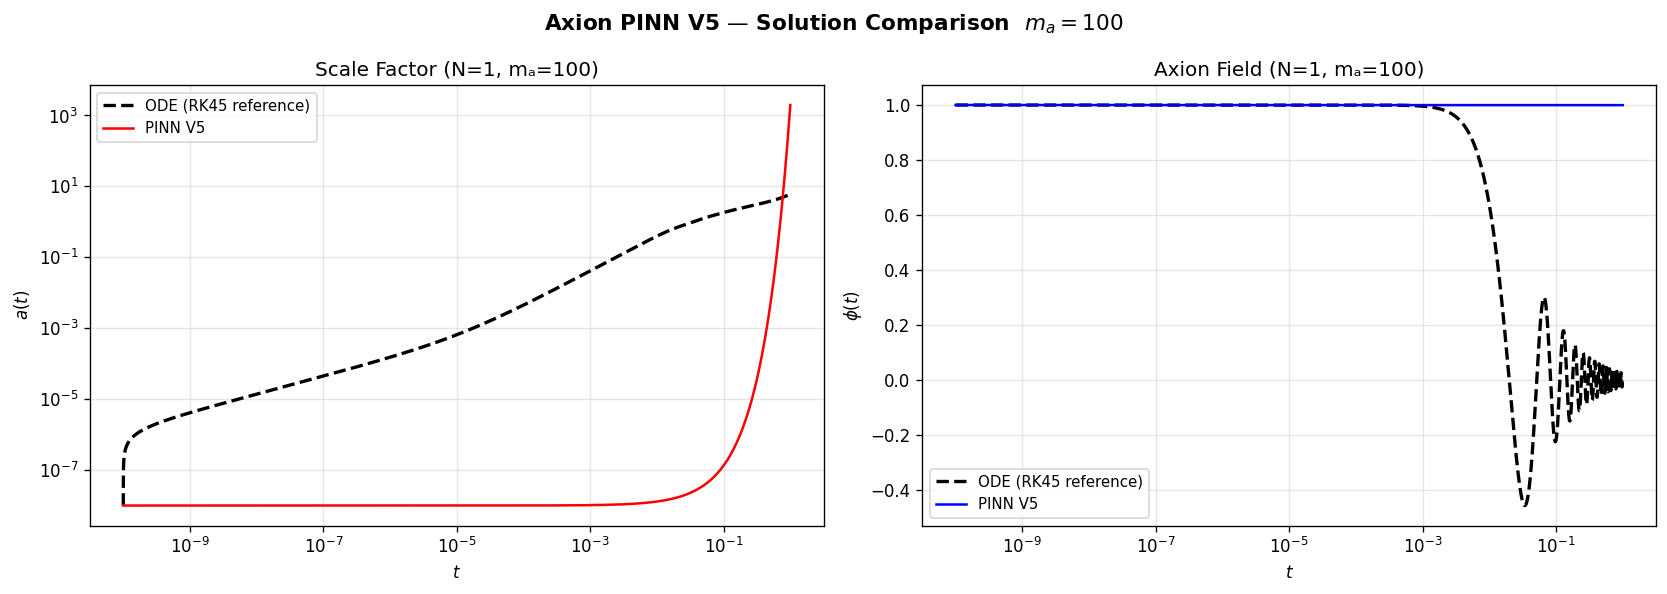

Saved: results_v5\solution_v5.png


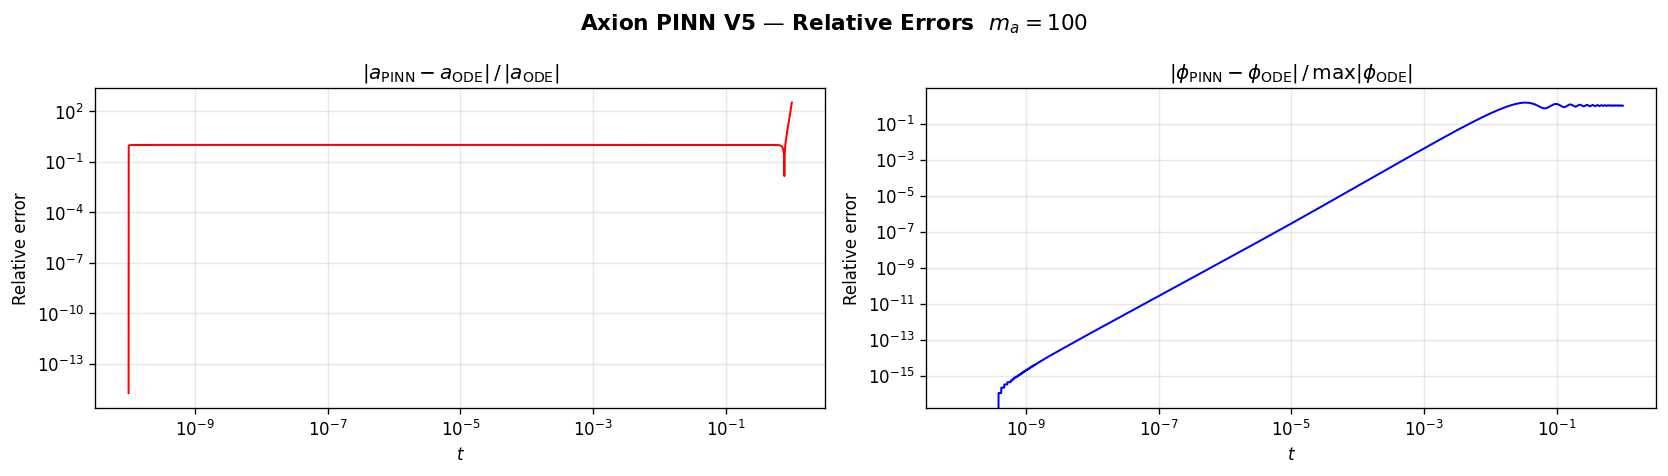

Saved: results_v5\errors_v5.png


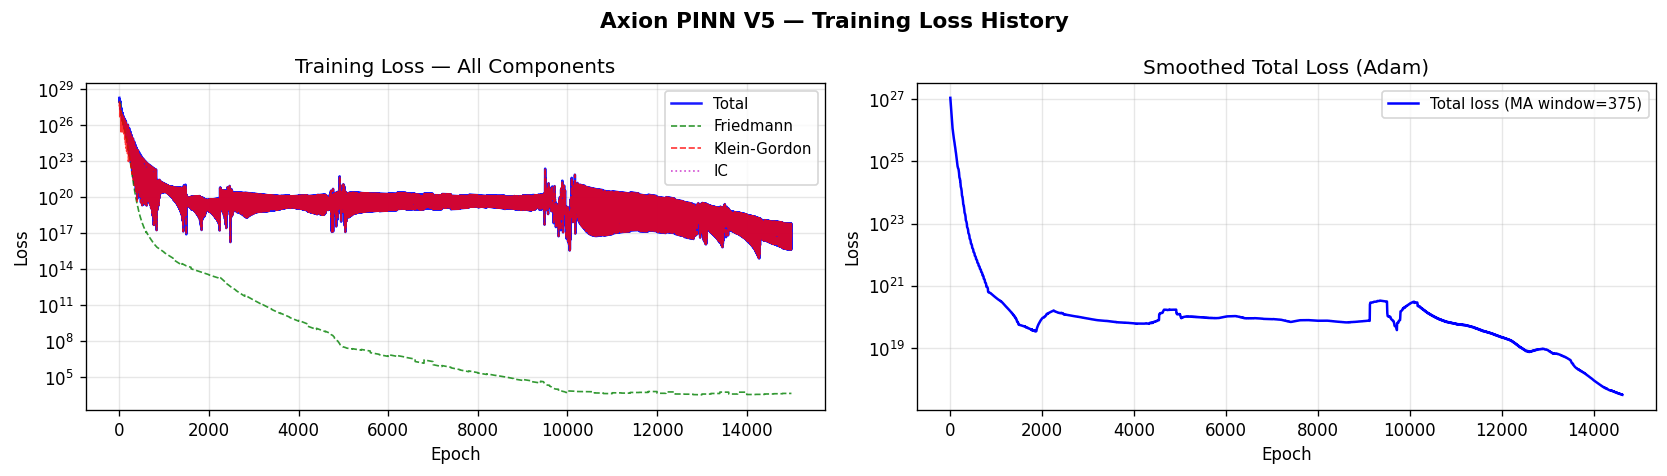

Saved: results_v5\loss_v5.png

  PINN V5 — IC Verification
  a(t_init)  : PINN=1.000000e-08  |  ODE=1.000000e-08  |  true=1.000000e-08
  φ(t_init)  : PINN=1.000000  |  ODE=1.000000  |  true=1.000000

  PINN V5 — Global Error Metrics
  a(t)  : max_rel=3.251e+02   mean_rel=1.592e+00
  φ(t)  : max_rel=1.457e+00  mean_rel=2.072e-01


In [8]:
# ─── Step 6: Evaluate and visualise ──────────────────────────────────────────
a_pred, phi_pred = evaluate_and_plot(
    solver,
    sol_ref,
    PARAMS,
    save_dir = 'results_v5',
    tag      = f'N=1, mₐ={PARAMS["ma"]:.0f}',
)
